Assignment2 - Analytical Model Choice & Customer Segmentation

In [12]:
# Import Libraries + Load Dataset

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("Retail_Customer_Insights_v2.xlsx")

# Preview data
df.head()

,customer_id,age,annual_income,spending_score,online_visits,purchase_frequency,avg_transaction_value,discount_usage,membership_years,region,preferred_channel,churn_risk
0,1,26,112021,65,12,3,397.30,0.28,1,East,Online,0
1,2,23,99521,40,11,6,NaN,0.43,5,North,Online,0
2,3,53,23590,7,9,10,337.76,0.23,2,North,Hybrid,0
3,4,67,67729,10,7,5,191.28,0.96,7,South,Online,0
4,5,18,61836,11,16,10,211.76,0.00,10,South,Online,0


In [14]:
# Dataset Overview & Data Quality Check

# View structure of dataset
df.info()

# Check missing values in each column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            700 non-null    int64  
 1   age                    700 non-null    int64  
 2   annual_income          700 non-null    int64  
 3   spending_score         700 non-null    int64  
 4   online_visits          700 non-null    int64  
 5   purchase_frequency     700 non-null    int64  
 6   avg_transaction_value  651 non-null    float64
 7   discount_usage         700 non-null    float64
 8   membership_years       700 non-null    int64  
 9   region                 700 non-null    object 
 10  preferred_channel      700 non-null    object 
 11  churn_risk             700 non-null    int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 65.8+ KB


customer_id               0
age                       0
annual_income             0
spending_score            0
online_visits             0
purchase_frequency        0
avg_transaction_value    49
discount_usage            0
membership_years          0
region                    0
preferred_channel         0
churn_risk                0
dtype: int64

In [16]:
# Handle Missing Values

# Fill missing values with median (robust to outliers)
df['avg_transaction_value'] = df['avg_transaction_value'].fillna(
    df['avg_transaction_value'].median()
)

# Verify missing values are resolved
df.isnull().sum()

customer_id              0
age                      0
annual_income            0
spending_score           0
online_visits            0
purchase_frequency       0
avg_transaction_value    0
discount_usage           0
membership_years         0
region                   0
preferred_channel        0
churn_risk               0
dtype: int64

In [18]:
# Feature Selection + Train/Test Split

from sklearn.model_selection import train_test_split

# Drop ID column (not useful for prediction)
X = df.drop(columns=['customer_id', 'churn_risk'])
y = df['churn_risk']

# 70/30 split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Check shapes
X_train.shape, X_test.shape

((490, 10), (210, 10))

In [20]:
# Preprocessing (Scaling + Encoding)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [22]:
# Ensemble Model (Random Forest)

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Build pipeline (preprocessing + model)
rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# 5-fold cross-validation on training set
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

# Results
print("Random Forest CV Mean F1:", rf_cv_scores.mean())
print("Random Forest CV Std:", rf_cv_scores.std())

Random Forest CV Mean F1: 0.8411779448621554
Random Forest CV Std: 0.0956739663112421


In [24]:
# SVM Model (RBF Kernel)

from sklearn.svm import SVC

# Build SVM pipeline
svm_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVC(kernel='rbf'))
])

# 5-fold cross-validation on training set
svm_cv_scores = cross_val_score(
    svm_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

# Results
print("SVM CV Mean F1:", svm_cv_scores.mean())
print("SVM CV Std:", svm_cv_scores.std())

SVM CV Mean F1: 0.6987390987390988
SVM CV Std: 0.08592951269031449


In [26]:
# Fit Final Models

# Fit Random Forest
rf_model.fit(X_train, y_train)

# Fit SVM
svm_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [28]:
# Test Set Predictions

# Random Forest predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# SVM predictions
svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.decision_function(X_test)

In [30]:
# Evaluation Metrics

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Random Forest metrics
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

# SVM metrics
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

# Print results
print("Random Forest - Precision:", rf_precision)
print("Random Forest - Recall:", rf_recall)
print("Random Forest - F1:", rf_f1)
print("Random Forest - ROC-AUC:", rf_auc)

print("\nSVM - Precision:", svm_precision)
print("SVM - Recall:", svm_recall)
print("SVM - F1:", svm_f1)
print("SVM - ROC-AUC:", svm_auc)

Random Forest - Precision: 1.0
Random Forest - Recall: 0.782608695652174
Random Forest - F1: 0.8780487804878049
Random Forest - ROC-AUC: 0.9842258748674444

SVM - Precision: 0.8666666666666667
SVM - Recall: 0.5652173913043478
SVM - F1: 0.6842105263157895
SVM - ROC-AUC: 0.9316012725344645


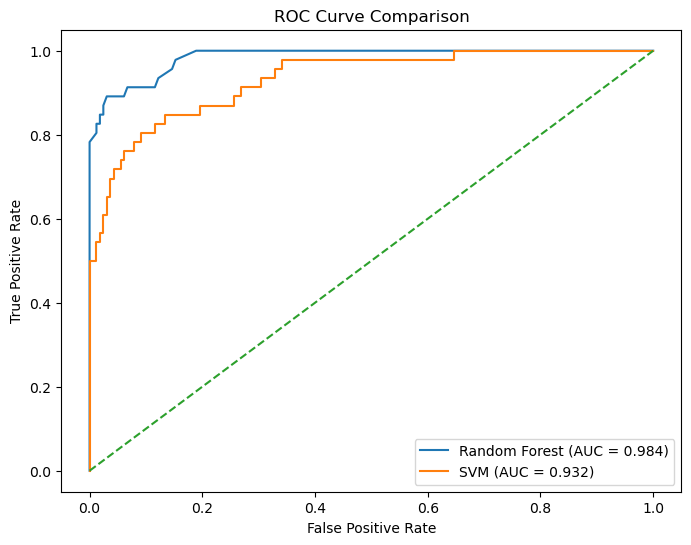

In [32]:
# ROC Curve Comparison

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Random Forest ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = {:.3f})'.format(rf_auc))
plt.plot(svm_fpr, svm_tpr, label='SVM (AUC = {:.3f})'.format(svm_auc))

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [34]:
# Preprocessing for Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate features (no target)
X_cluster = df.drop(columns=['customer_id', 'churn_risk'])

# Identify feature types
num_features = X_cluster.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_cluster.select_dtypes(include=['object']).columns

# Preprocessing pipeline for clustering
cluster_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Transform data
X_cluster_scaled = cluster_preprocessor.fit_transform(X_cluster)

In [36]:
# K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Store results
k_values = [2, 3, 4, 5]
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    score = silhouette_score(X_cluster_scaled, labels)
    silhouette_scores.append(score)
    
    print(f"k = {k}, Silhouette Score = {score}")

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

k = 2, Silhouette Score = 0.08228526059527183
k = 3, Silhouette Score = 0.07799706148874377
k = 4, Silhouette Score = 0.07523786682534604
k = 5, Silhouette Score = 0.07470455917330636


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


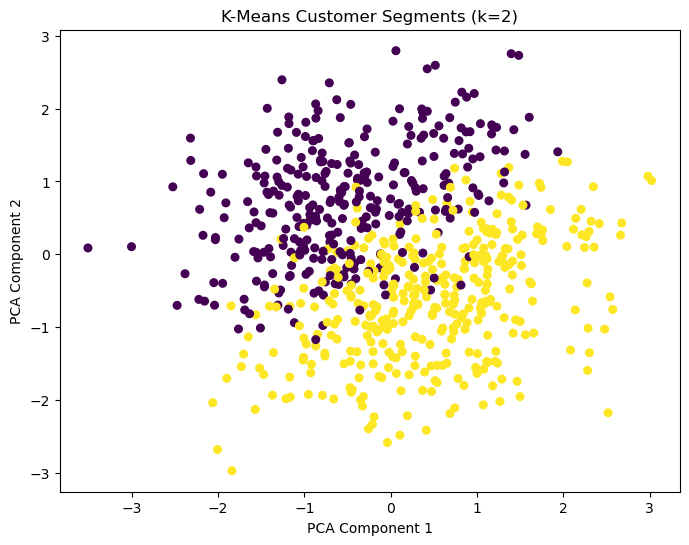

In [38]:
# STEP 14: K-Means Cluster Visualization (2D PCA)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization only
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_cluster_scaled)

# Fit KMeans with best k (based on previous result: k=2)
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans_final.fit_predict(X_cluster_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='viridis', s=30)

plt.title("K-Means Customer Segments (k=2)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [40]:
# STEP 15: DBSCAN Clustering

from sklearn.cluster import DBSCAN

# Try 2 eps values (as required)
eps_values = [0.5, 1.0]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_cluster_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    print(f"eps = {eps}")
    print(f"Clusters formed: {n_clusters}")
    print(f"Noise points: {n_noise}")
    print("---------------------------")

eps = 0.5
Clusters formed: 0
Noise points: 700
---------------------------
eps = 1.0
Clusters formed: 0
Noise points: 700
---------------------------


In [1]:
# Clustering Interpretation Summary

print("=== K-Means Summary ===")
print("K-Means showed weak but structured segmentation based on silhouette scores (~0.07 - 0.08).")
print("Best k = 2, but overall cluster separation is weak which indicates overlapping customer behavior.")

print("\n=== DBSCAN Summary ===")
print("DBSCAN failed to form meaningful clusters for all epsilon values tested.")
print("All points were classified as noise, indicating no strong density-based structure.")

print("\n=== Final Interpretation ===")
print("Customer behavior appears continuous rather than naturally segmented.")
print("K-Means provides limited exploratory grouping, while DBSCAN is not suitable for this dataset.")

=== K-Means Summary ===
K-Means showed weak but structured segmentation based on silhouette scores (~0.07 - 0.08).
Best k = 2, but overall cluster separation is weak which indicates overlapping customer behavior.

=== DBSCAN Summary ===
DBSCAN failed to form meaningful clusters for all epsilon values tested.
All points were classified as noise, indicating no strong density-based structure.

=== Final Interpretation ===
Customer behavior appears continuous rather than naturally segmented.
K-Means provides limited exploratory grouping, while DBSCAN is not suitable for this dataset.
